### Introduction


This simulation models epidemic spreading on a contact network using the SIR framework.

Unlike classical SIR models that assume homogeneous mixing, individuals are represented as nodes in a network, and infections spread only through connections.



The network structure is generated using a scale-free network model, which reflects the heterogeneous connectivity often observed in real-world social networks.

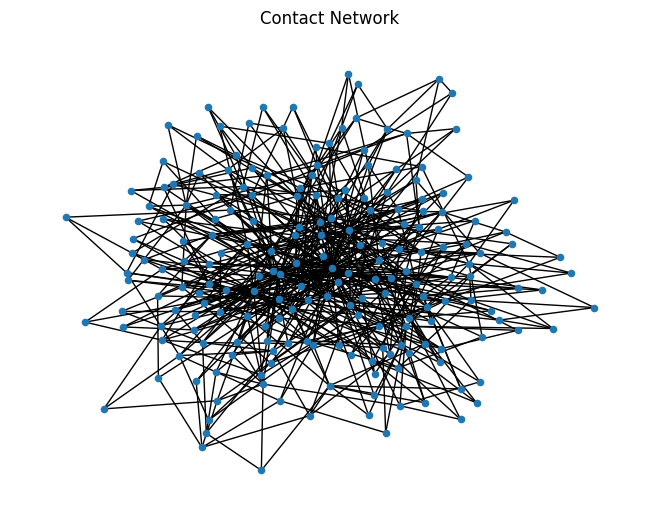

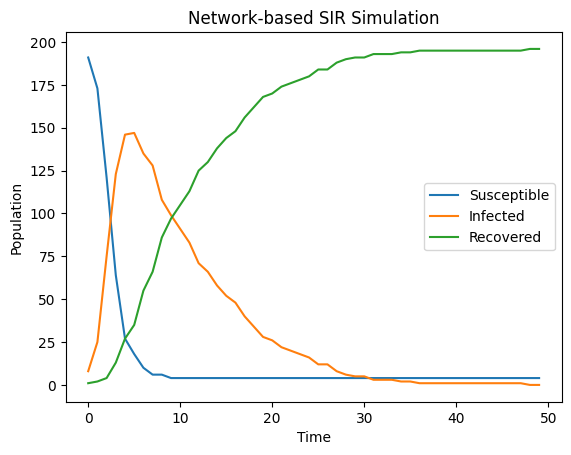

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
N = 200
G = nx.barabasi_albert_graph(N,3)

nx.draw(G,node_size=20)
plt.title("Contact Network")
plt.show()

S = set(G.nodes())
I = set(random.sample(list(G.nodes()),3))
R = set()

S -= I

beta = 0.3
gamma = 0.1

steps = 50

S_history = []
I_history = [] 
R_history = []

for t in range(steps):

    new_infected = set ()
    new_recovered = set()

    for i in I:
        for neighbor in G.neighbors(i):
            if neighbor in S and random.random() < beta:
                new_infected.add(neighbor)

        if random.random() < gamma:
            new_recovered.add(i)

    S -= new_infected
    I |= new_infected

    I -= new_recovered
    R |= new_recovered

    S_history.append(len(S))
    I_history.append(len(I))
    R_history.append(len(R))

plt.plot(S_history, label="Susceptible")
plt.plot(I_history, label="Infected")
plt.plot(R_history, label="Recovered")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Network-based SIR Simulation")

plt.legend()
plt.show()

### Result


The simulation shows how infections propagate through a networked population.

Because some nodes have many connections, infections can spread rapidly once highly connected nodes become infected.



This demonstrates how network topology strongly influences epidemic dynamics.

### Conclusion


Network-based epidemic models provide a more realistic representation of disease spreading compared to homogeneous models.

Future work could explore different network structures or targeted vaccination strategies to mitigate outbreaks.